# Python coding skills for statistics Part 2

This notebook contains the code examples for the blog post
[Python coding skills for statistics Part 2](https://docs.google.com/document/d/1XusbfJoZ7CQxbeWPPXMM84BA-VeUn8lkPUuUy7RcW8M/edit),
which explains how Python can help us better understand probability and statistics concepts. I've reproduced the essential parts of the narrative here (in abdidged form) so the notebook should be readable on its own.

The benefit of the notebook version is you can play with the code examples interactively. To run a code cell, press the play button in the menu bar, or use the keyboard shortcut **SHIFT+ENTER**.

### Notebook setup

In [1]:
# Install stats library
%pip install --quiet ministats 

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Figures setup
import matplotlib.pyplot as plt
import seaborn as sns

plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    style="whitegrid",
    rc={'figure.figsize': (5, 3)},
)
# High-resolution figures please
%config InlineBackend.figure_format = 'retina'

def savefig(fig, filename):
    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight", pad_inches=0)

<Figure size 640x480 with 0 Axes>

## Introduction

In notebook, I want to introduce you to some core statistics concepts from a computational perspective. By writing simple Python code (mostly `for` loops), you can understand some core ideas of statistics. If you're not familiar with Python at all, I recommend you read [Part 1 of the blog post series](https://minireference.com/blog/python-for-stats/) and consult [this notebook](./python_for_stats.ipynb) first.

**TL;DR** My main realization from working on this book is that the hands-on computational approach to statistical calculations makes learning concepts much more straightforward, as compared to the classical way of teaching which is based on formulas and procedures. This is why we'll present the key ideas using Python code and visualizations, which should be accessible to most readers.


The statistical analyses examples in this notebook are taken from the textbook [No Bullshit Guide to Stats](https://nobsstats.com/), which you can check out if you want to learn more statistics.

Let's start with what this is all about…

### Context

### Statistical inference

The goal of most statistical analysis is inferential statistics, which is the process of making inferences about a population based on a sample from that population. We usually assume the population is described by some probability distribution, which is a mathematical description for the type of individuals in the population.

For example, the population of IQ scores in the is know to follow the normal distribution with mean $\mu$ (read miu) and standard deviation $\sigma$ (sigma), which we denote as $\mathcal{N}(\mu,\sigma)$. By convention, we denote the parameters of the population using Greek letters. You can think of the parameters $\mu$ and $\sigma$ as control knobs on the distribution that determine its shape.

It is usually prohibitively expensive to measure the IQ score of every individual in the population, so instead we obtain a random sample of individuals and measure their IQ scores. The goal of statistical inference is to learn information about the population based on a sample, as illustrated by the backward arrow in Figure 1. Specifically, we want to find the population parameters $\mu$  and $\sigma$.

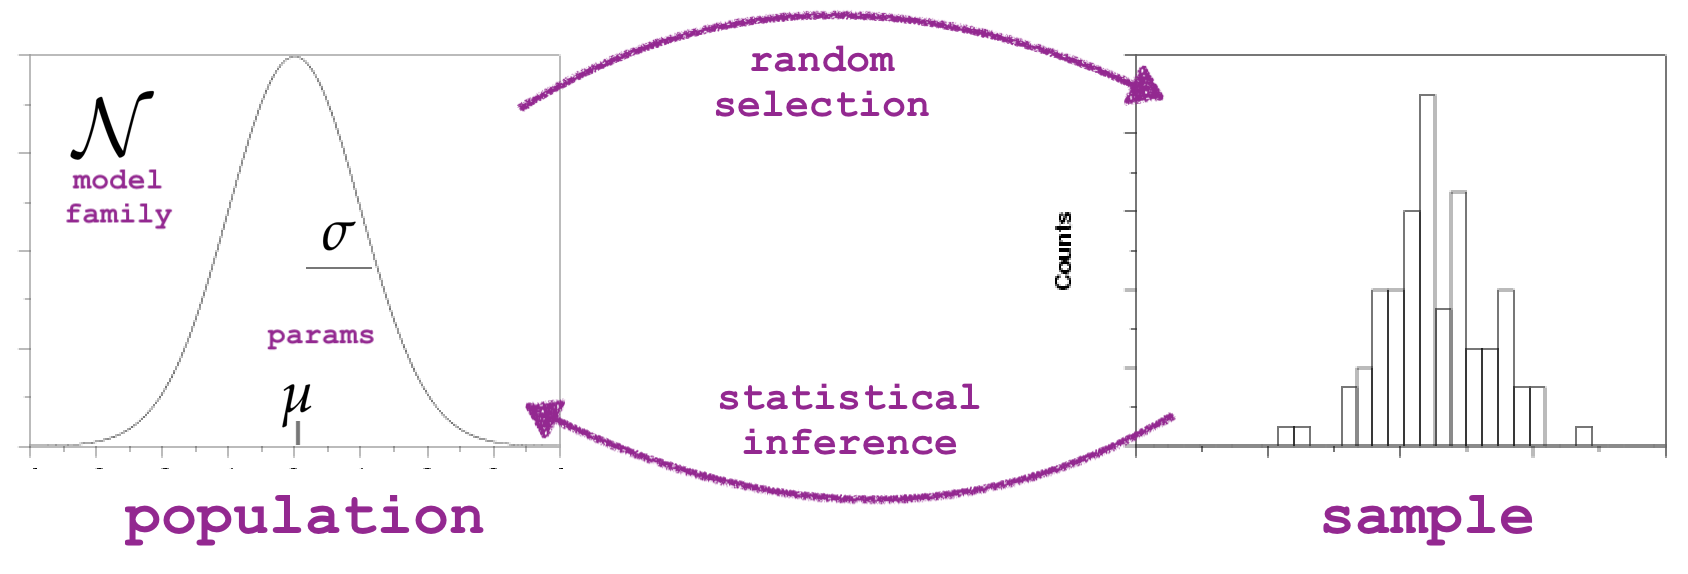
**Figure 1**. Illustration of the random selection mechanism which generates the data sample
and the statistical inference process, which tries to guess the population parameters.



### The modern statistics curriculum

Many statistics techniques of the classical curriculum were developed in a time with limited computation capabilities. Using a computational approach makes many  "hard" topics in statistics much easier to understand. There is a growing movement in statistics education called "modern statistics" that puts the focus on using computers for statistical calculations.

The two techniques from the modern statistics curriculum we'll discuss in this blog post are:
- **Simulation**: Direct computational approach for doing probability calculations by simulating tens of thousands of samples from the relevant population. We can then calculate relevant quantities directly from the samples instead of using math formulas. 
- **Resampling methods**: This is an umbrella term for various clever techniques that reuse data from observed sample to simulate the variability in the population.

The simulation and resampling methods are computationally expensive, but they apply for **any distribution** and allows us to compute **any quantity of interest**—not just quantities for which statisticians have found formulas.

## Example data analysis scenario

We'll use an example to ground the discussions in the rest of the notebook. 

### IQ scores data

Consider the following dataset,
which consists of IQ scores of 30 students who took a "smart drug" ☕.
The IQ scores are recorded in the following list.

In [3]:
iqs = [ 95.7, 100.1,  95.3, 100.7, 123.5, 119.4,  84.4, 109.6,
       108.7,  84.7, 111.0,  92.1, 138.4, 105.2,  97.5, 115.9,
       104.4, 105.6, 104.8, 110.8,  93.8, 106.6,  71.3, 130.6,
       125.7, 130.2, 101.2, 109.0, 103.8,  96.7]

In [4]:
# sample size (n)
len(iqs)

30

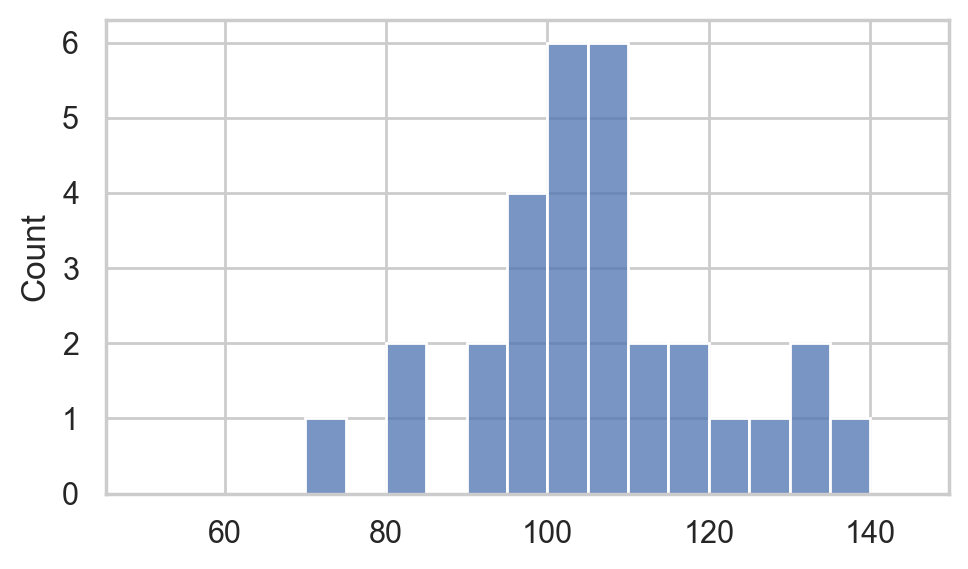

In [5]:
import seaborn as sns
sns.histplot(iqs, bins=range(50,150,5));

savefig(plt.gcf(), "figures/histplot_iqs.png")

### Descriptive statistics

In [6]:
from statistics import mean
mean(iqs)

105.89

In [7]:
from statistics import stdev as std
std(iqs)

14.658229417469641

### Statistical inference by eyeball

Move the sliders to choose the model parameters that best match the data.

In [8]:
import numpy as np
from scipy.stats import norm
from ipywidgets import interact

def plot_pop_and_sample(mu, sigma):
    # 1. Plot histogram of sample
    ax = sns.histplot(x=iqs, stat="density", bins=range(50,150,5), label="data")
    # 2. Plot probability density function of population model
    rvX = norm(mu, sigma)
    xs = np.linspace(50, 150, 1000)
    fXs = rvX.pdf(xs)
    sns.lineplot(x=xs, y=fXs, ax=ax, c="C0", label="model")
    print(f"current population model guess: X ~ N(mu={mu}, sigma={sigma})")

interact(plot_pop_and_sample, mu=(50,150,1), sigma=(3,40,1));

interactive(children=(IntSlider(value=100, description='mu', max=150, min=50), IntSlider(value=21, description…

### Research questions

The main research question we want to answer based on the IQ scores data is whether the smart drug had an effect on or not. We know the average IQ score is $\mu=100$ for the population in general (not the individuals from this experiment) with standard deviation $\sigma=15$ IQ points. If we compare the mean IQ score we observed in the sample of students who took the smart drug $\overline{\tt{iqs}}=105.89$  to people in the mean of the general population $\mu=100$, we see the students on the smart drug did better, which suggests the drug is effective.

On the other hand, the standard deviation of IQ scores is 15, which means that variations of +/- 15 around the mean of 100 are common, so perhaps observing a difference between observed mean and the theoretical mean of 5.89 is not uncommon.

This is precisely the situation why we need the tools of statistical inference. We'll use the hypothesis testing procedure to calculate how "surprising" it is to observe a difference of 5.89 from the expected population mean, and thus provide a principled answer to the question if the smart drug is effective.

Before we get to the hypothesis testing procedure, we'll need to introduce some prerequsite concepts: probability models and sampling distribributions.


## Probability models

The concept of a random variable, denoted $X$, is a key building block in probability theory. The random variable $X$ is a quantity that can take on different values, and it is described by a probability distribution function $f_X$, which we use to compute the probability of different possible outcomes of the random variable $X$.

When learning about random variables, readers are usually exposed to numerous formulas and equations for describing probability distributions. These math equations can be hard to understand, especially for people who haven't done math recently. Using computer models, however, makes probability concepts much more accessible. Specifically, computers give us two additional points of view of the math equations:

- **Visualizations**. Plotting the probability distribution $f_X$ for the random variable $X$ gives you a visual representation of the possible values this variable can have.
- **Computer-assisted calculations**. Probability calculations can be done easily using Python as a calculator.

### Computer models for random variables

The standard normal distribution is denoted $Z \sim \mathcal{N}(\mu=0,\sigma=1)$,
where $Z$ is the name has the probability density function:

$$
    f_Z(z) = \tfrac{1}{\sqrt{2\pi}} e^{ - \frac{1}{2}z^2}.
$$

The standard normal is a special case of the general normal $\mathcal{N}(\mu, \sigma)$
where $\mu$ is the mean and $\sigma$ is the standard deviation.


We can use the predefined probability model from the Python module `scipy.stats` whenever we need to do probability calculations.
To create a computer model for the standard normal random variable $Z \sim \mathcal{N}(\mu=0, \sigma=1)$,
we need to import the `norm` model family form `scipy.stats`
then create the random variable object `norm(0,1)`.

In [9]:
from scipy.stats import norm
rvZ = norm(0, 1)

The model first parameter is the mean $\mu=0$,
which is also know as the *location* parameter of the distribution–where it is centred.
The second parameter is the standard deviation $\sigma=1$,
which is also known as the *scale* parameter and controls the width.
The Python keyword for the model parameters are `loc` and `scale`,
so another way to create the random variable object `rvZ` is `norm(loc=0, scale=1)`.

The probability density function $f_Z$ is available as the `.pdf` method on the model `rvZ`.

In [10]:
rvZ.pdf(1)

0.24197072451914337

### Probability model visualizations

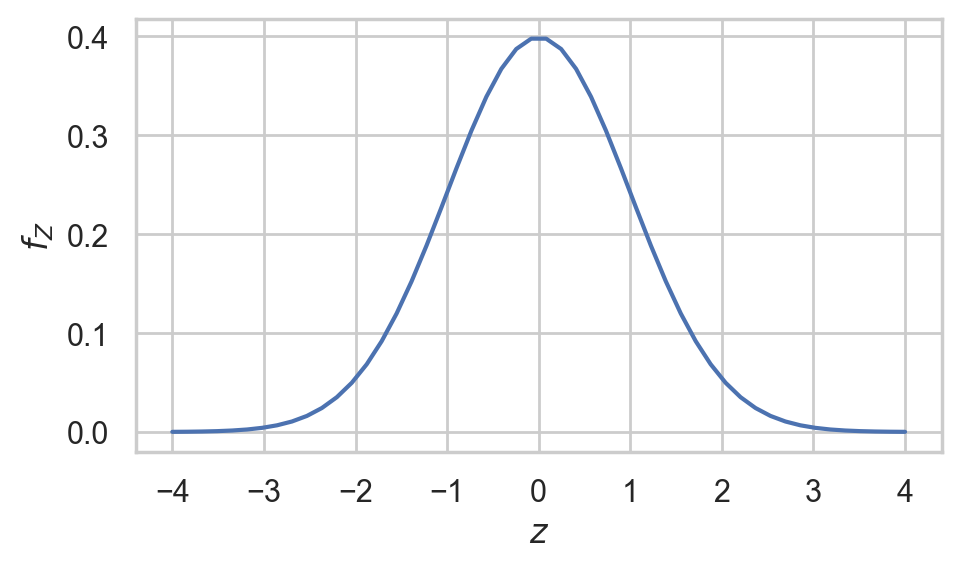

In [11]:
import numpy as np
zs = np.linspace(-4, 4)
fZs = rvZ.pdf(zs)
ax = sns.lineplot(x=zs, y=fZs)
ax.set_xticks(range(-4,5))
ax.set_xlabel("$z$")
ax.set_ylabel("$f_Z$")
savefig(ax.figure, "figures/pdf_of_rvZ.png")

The above graph tells you everything you need to know about the random variable $Z$.
The possible values of $Z$ are concentrated around the mean $\mu=0$.
The region of highest density is roughly between $z=-1$ and $z=1$,
with most of values between $z=-2$ and $z=2$,
then the probability density drops off to (almost) zero for $z<-3$ and $z>3$.

### Doing probability calculations

Calculating probabilities with the continuous random variable $Z$ requires using *integration*,
which the process of computing the total area under a curve for some region.
For example, 
the probability that the random variable $Z$ will have a value somewhere
between $1$ and $2$ is defined as $\textrm{Pr}(\{1 \leq Z \leq 2\}) = \int_{z=1}^{z=2} f_Z(z) dz$.

In [12]:
from scipy.integrate import quad
quad(rvZ.pdf, a=1, b=2)[0]

0.13590512198327787

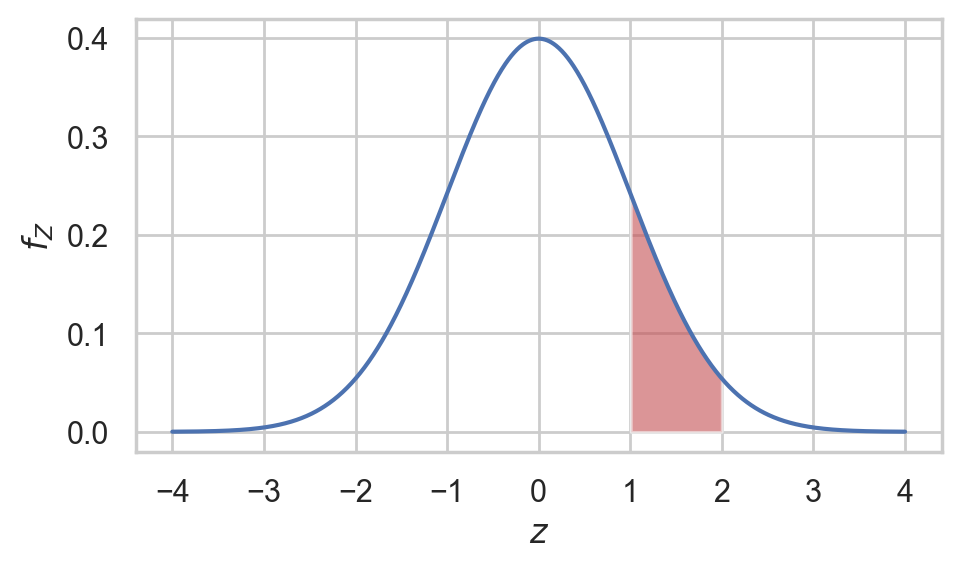

In [13]:
zs = np.linspace(-4, 4, 1000)
fZs = rvZ.pdf(zs)
ax = sns.lineplot(x=zs, y=fZs)
mask = (1 < zs) & (zs < 2)
ax.fill_between(zs[mask], y1=fZs[mask], alpha=0.6, facecolor="C3")
ax.set_xticks(range(-4,5))
ax.set_xlabel("$z$")
ax.set_ylabel("$f_Z$")
# TODO: add text label "$\{1 \leq Z \leq 2\}$" and arrow pointing towards region
savefig(ax.figure, "figures/pdf_of_rvZ_highlight_1_to_2.png")

The probability of the event $\{1 \leq Z \leq 2\}$ corresponds to the area in red.

### Random samples

To generate a random sample of size $n$ from the random variable `rvZ`,
call the method `rvZ.rvs(n)`.

In [14]:
np.random.seed(46)
zs = rvZ.rvs(10)
zs

array([ 0.58487584,  1.23119574,  0.82190026, -0.79922836,  0.41205323,
       -0.17615661, -0.07317197, -0.56566639, -0.09346524,  0.85730108])

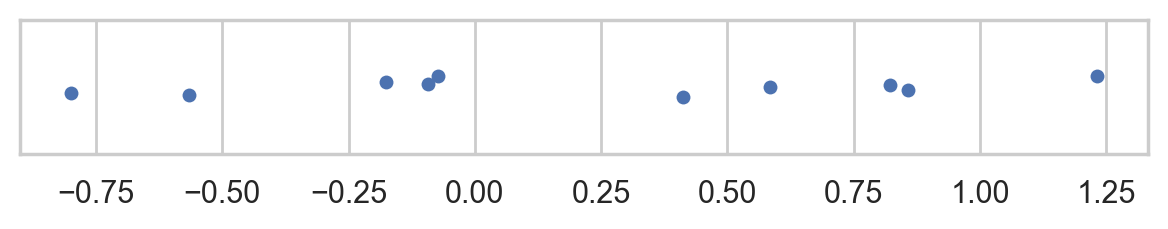

In [15]:
with plt.rc_context({"figure.figsize":(6,1.3)}):
    sns.stripplot(x=zs)
    savefig(plt.gcf(), "figures/sample_from_rvZ_n10.png")

### Normal distributions with different parameters
The standard normal distribution $\mathcal{N}(\mu=0, \sigma=1)$ is just one representative of the family of normal distributions. The mean parameter  $\mu$ (the Greek letter mu) and standard deviation parameter $\sigma$ (the Greek letter sigma) control the shape of the normal distribution. We can experiment with the different choices of parameters for the normal model to see what shape of distribution we get.

Here are some examples of graphs of the normal distribution for different parameters $\mu$ and $\sigma$.

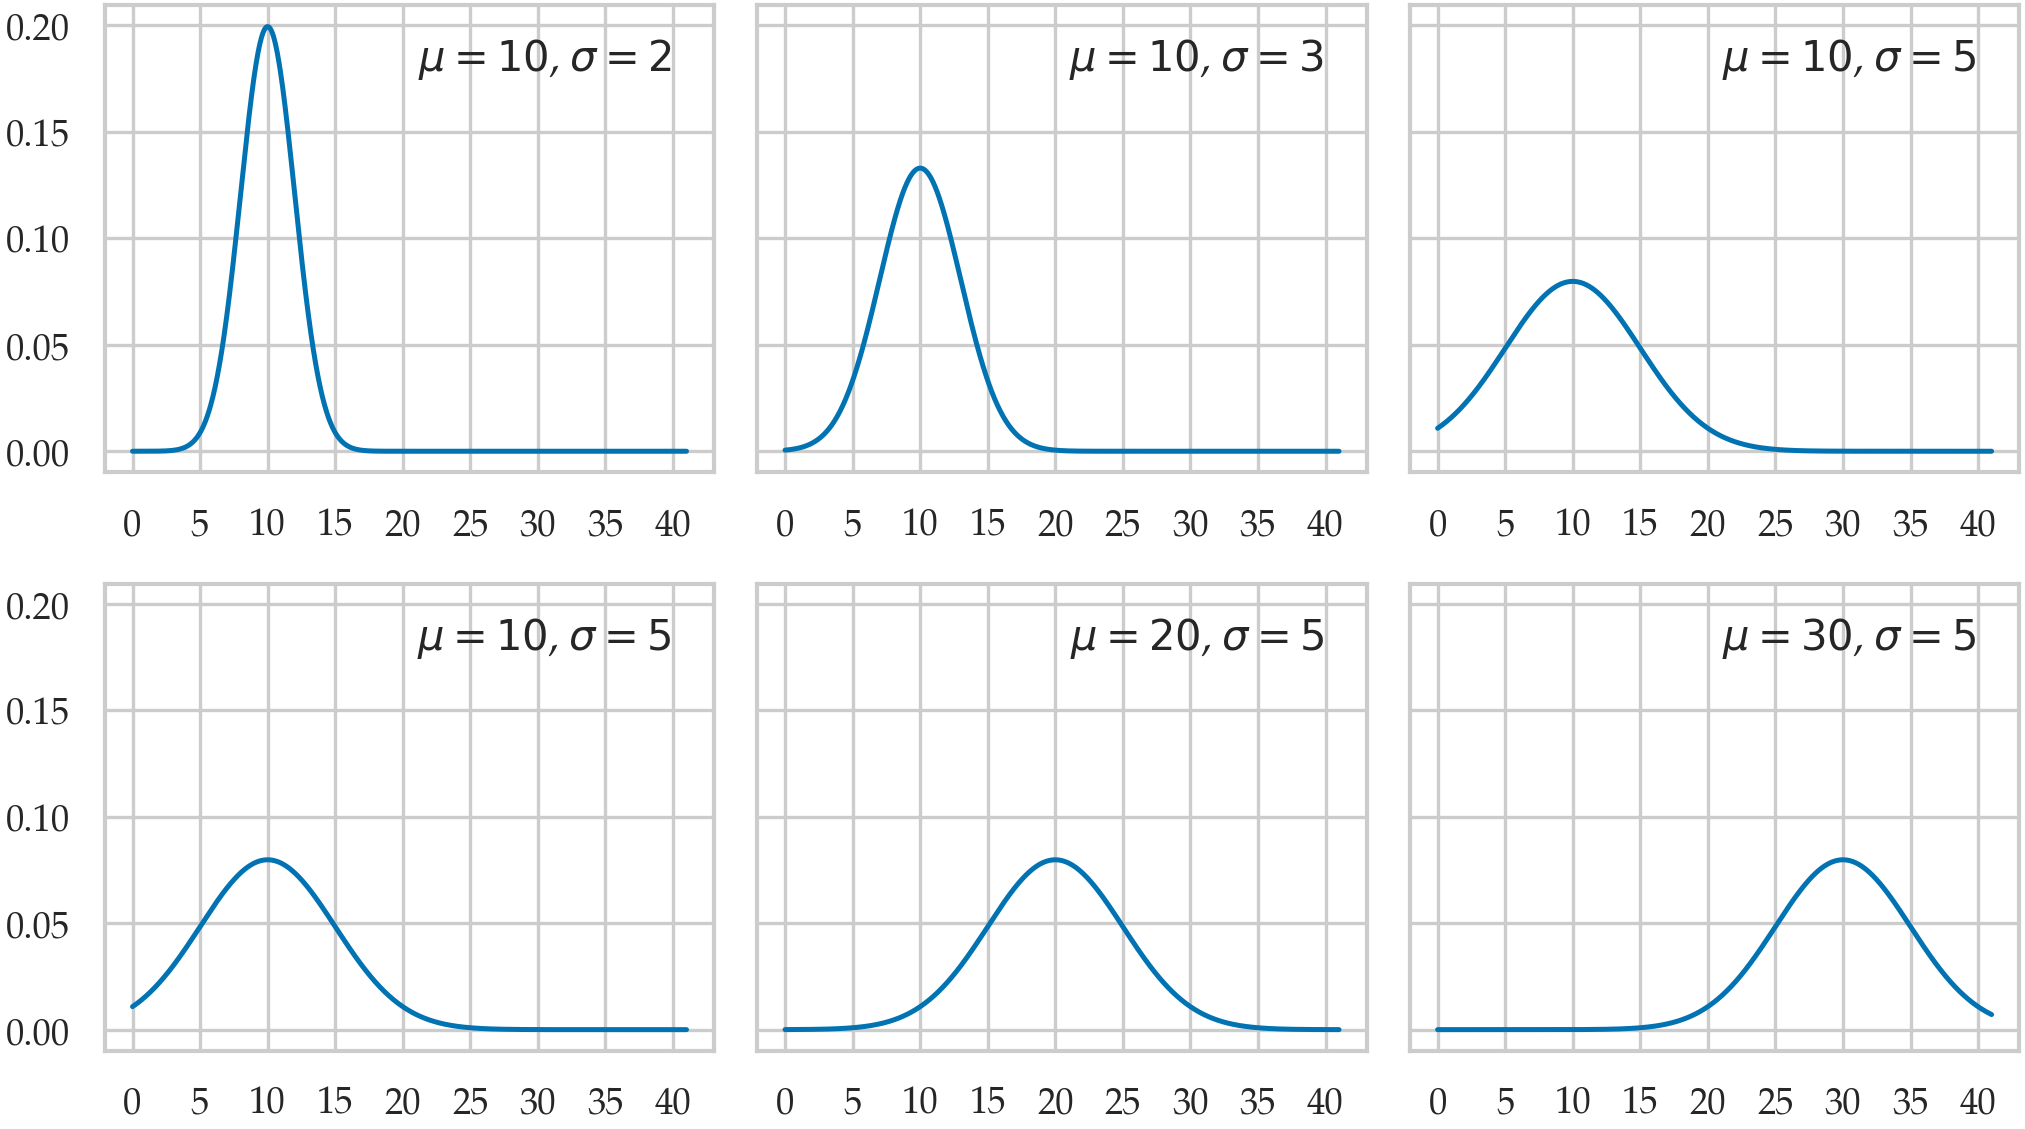


There are many of other probability distributions that can be useful for modelling various real world quantities. You can take a look at the probability graphs
of [discrete distribution here](https://nobsstats.com/notebooks/26_inventory_continuous_dists.html) and [continuous distributions here](https://nobsstats.com/notebooks/23_inventory_discrete_dists.html).

### Probability model for the general population

Let's now build the specific probability model we need for the analysis of the students' IQ scores.
We know the IQ scores in the general population has mean $\mu=100$ and standard deviation $\sigma=15$.
We will denote the general population as $X \sim \mathcal{N}(\mu=100,\sigma=15)$.


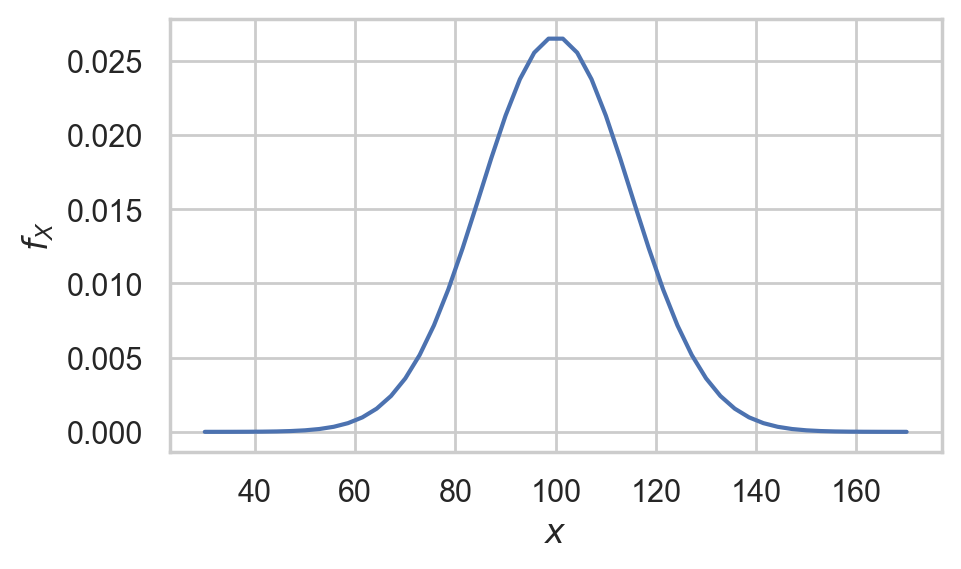

In [16]:
mu = 100
sigma = 15
rvX = norm(mu, sigma)

xs = np.linspace(30, 170)
ax = sns.lineplot(x=xs, y=rvX.pdf(xs));
ax.set_xlabel("$x$")
ax.set_ylabel("$f_{X}$")

savefig(plt.gcf(), "figures/samples_from_rvX_n30.png")

This is the distribution of IQ scores we can expect to observe for the general population.

### Random samples from the general population

We'll use the notation $\mathbf{X} = (X_1, X_2, \ldots, X_{30})$ to describe a *random sample* from the general population.

To get a idea of what these random samples look like,
we can generate $10$ samples $\mathbf{x}_1, \mathbf{x}_2, \mathbf{x}_3, \ldots, \mathbf{x}_{10}$ of size $n=30$ from $X \sim \mathcal{N}(\mu=100, \sigma=15)$ as follows.

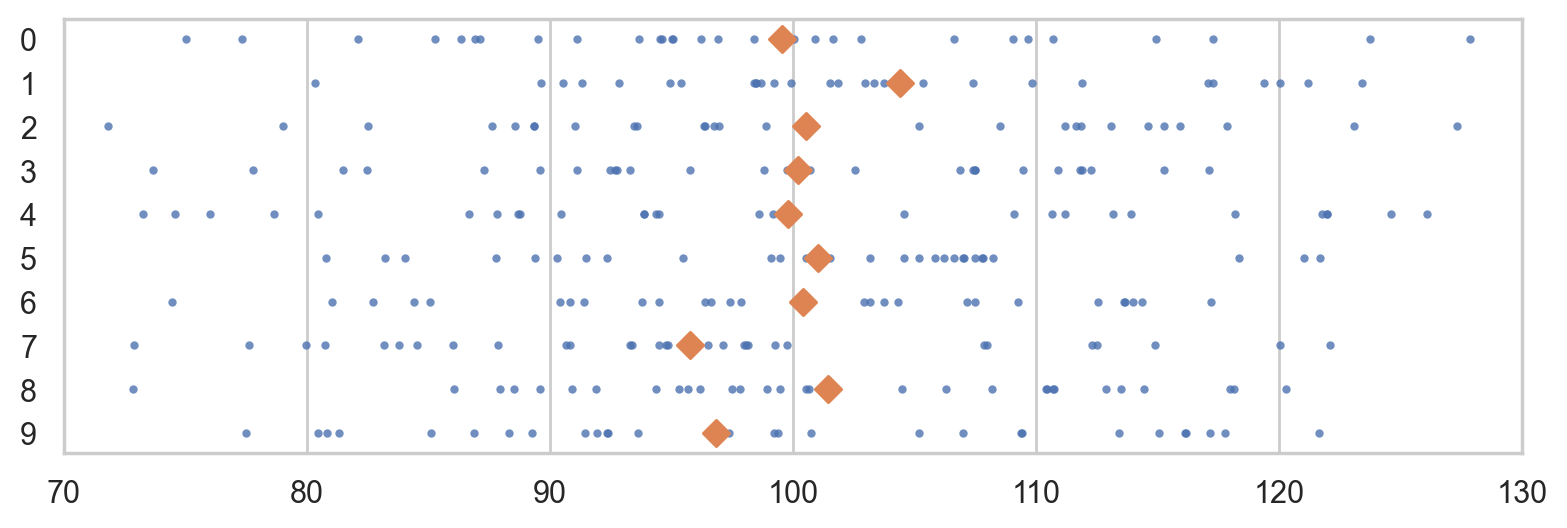

In [17]:
np.random.seed(5)

samples = [rvX.rvs(30) for i in range(10)]
with plt.rc_context({"figure.figsize":(8,2.8)}):
    ax = sns.stripplot(samples, orient="h", s=3, color="C0", alpha=0.8, jitter=0)
    ax.set_xlim([70,130])
    for i, sample in enumerate(samples):
        xbar = mean(sample)
        ax.scatter(xbar, i, marker="D", s=45, color="C1", zorder=10)

savefig(plt.gcf(), "figures/samples_from_rvX_n30.png")

The diamond markers indicate the position of the sample means computed from each sample:
$[\overline{\mathbf{x}}_1, \overline{\mathbf{x}}_2, \overline{\mathbf{x}}_3, \ldots, \overline{\mathbf{x}}_{10}]$.


In the next section we're going to talk about the distribution of the diamond shapes,
which correspond to the means computed from random samples.

## Sampling distributions

The *sampling distribution* of the mean for samples of size $n=30$ from the general population $X \sim \mathcal{N}(100,15)$ is the probability distribution of the random variable $\overline{\mathbf{X}} = \mathbf{Mean}(\mathbf{X})$,
where $\mathbf{X} = (X_1, X_2, \ldots, X_{30})$ is a *random sample* from $\mathcal{N}(100,15)$. The sampling distribution describes the kind of means we can expect to observe if
we compute the mean for a sample of size $n=30$ from the standard normal.


To visualize the sampling distribution of the mean $\overline{\mathbf{X}} = \texttt{mean}(\mathbf{X})$,
we can generate $N=1000$ samples from the population model:
$\mathbf{x}_1, \mathbf{x}_2, \mathbf{x}_3, \ldots, \mathbf{x}_{1000}$,
then plot a histogram of the means computed from the $1000$ random samples,
`xbars` = $[\overline{\mathbf{x}}_1, \overline{\mathbf{x}}_2, \overline{\mathbf{x}}_3, \ldots, \overline{\mathbf{x}}_{1000}]$,
where $\overline{\mathbf{x}}_j$ denotes the sample mean computed from the data in the $j$th sample,
$\overline{\mathbf{x}}_j = \texttt{mean}(\mathbf{x}_j)$.

In [18]:
N = 1000  # number of random samples
n = 30    # sample size

xbars = []
for j in range(0, N):
    sample = rvX.rvs(n)
    xbar = mean(sample)
    xbars.append(xbar)

# xbars[0:5]

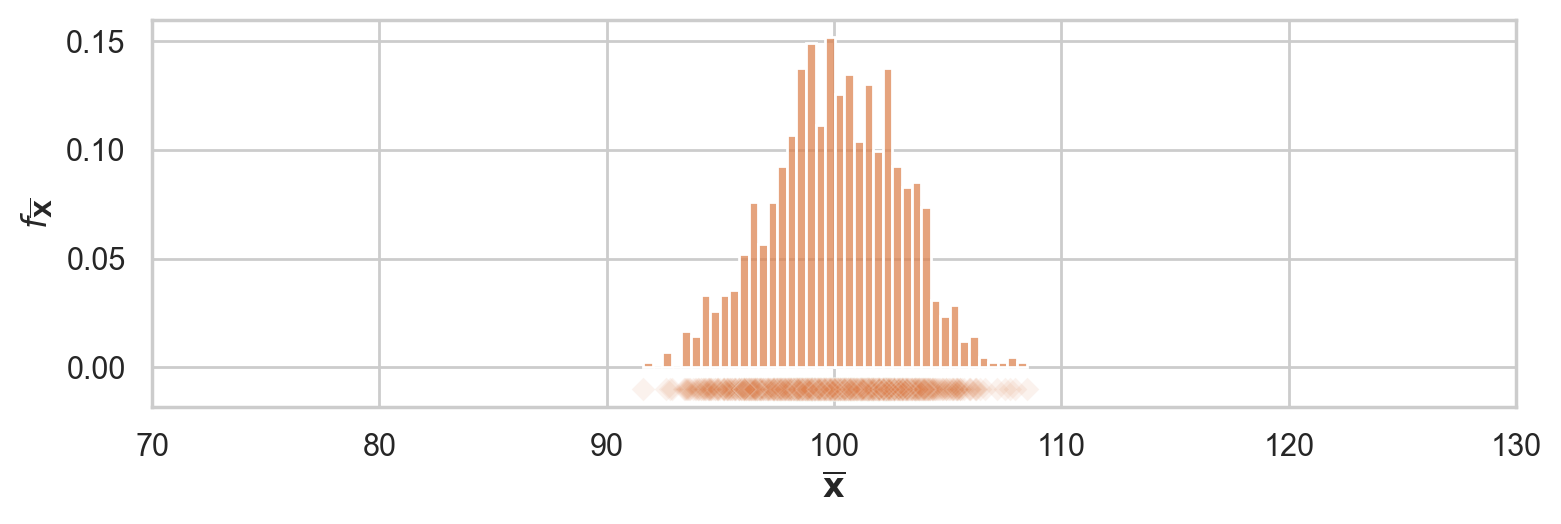

In [19]:
with plt.rc_context({"figure.figsize":(8,2.8)}):
    ax = sns.histplot(xbars, color="C1", bins=40, stat="density")
    ax.set_xlim([70,130])
    sns.scatterplot(x=xbars, y=-0.01, color="C1", marker="D", alpha=0.1, ax=ax)
    ax.set_xlabel("$\\overline{\\mathbf{x}}$")
    ax.set_ylabel("$f_{\\overline{\\mathbf{X}}}$");
    savefig(plt.gcf(), "figures/hist_sampling_dist_mean_rvX_n30_N1000.png")

The above figure shows the sampling distribution of the mean for samples of size $n=30$ from the general population model $X \sim \mathcal{N}(\mu=100, \sigma=15)$.
The histogram shows the "density of diamond shapes," and provides a representation of the sampling distribution of the mean $\overline{\mathbf{X}} = \tt{mean}(\mathbf{X})$.


### Two ways to work with sampling distributions

You can use either a math description (analytical formulas) or a computational description (simulations) for the sampling distribution. Although the two descriptions seem very different on the surface, they both describe the same underlying concept. I've compiled a little list of the key properties of the estimator $\tt{mean}$ to show the correspondences between two types of descriptions.


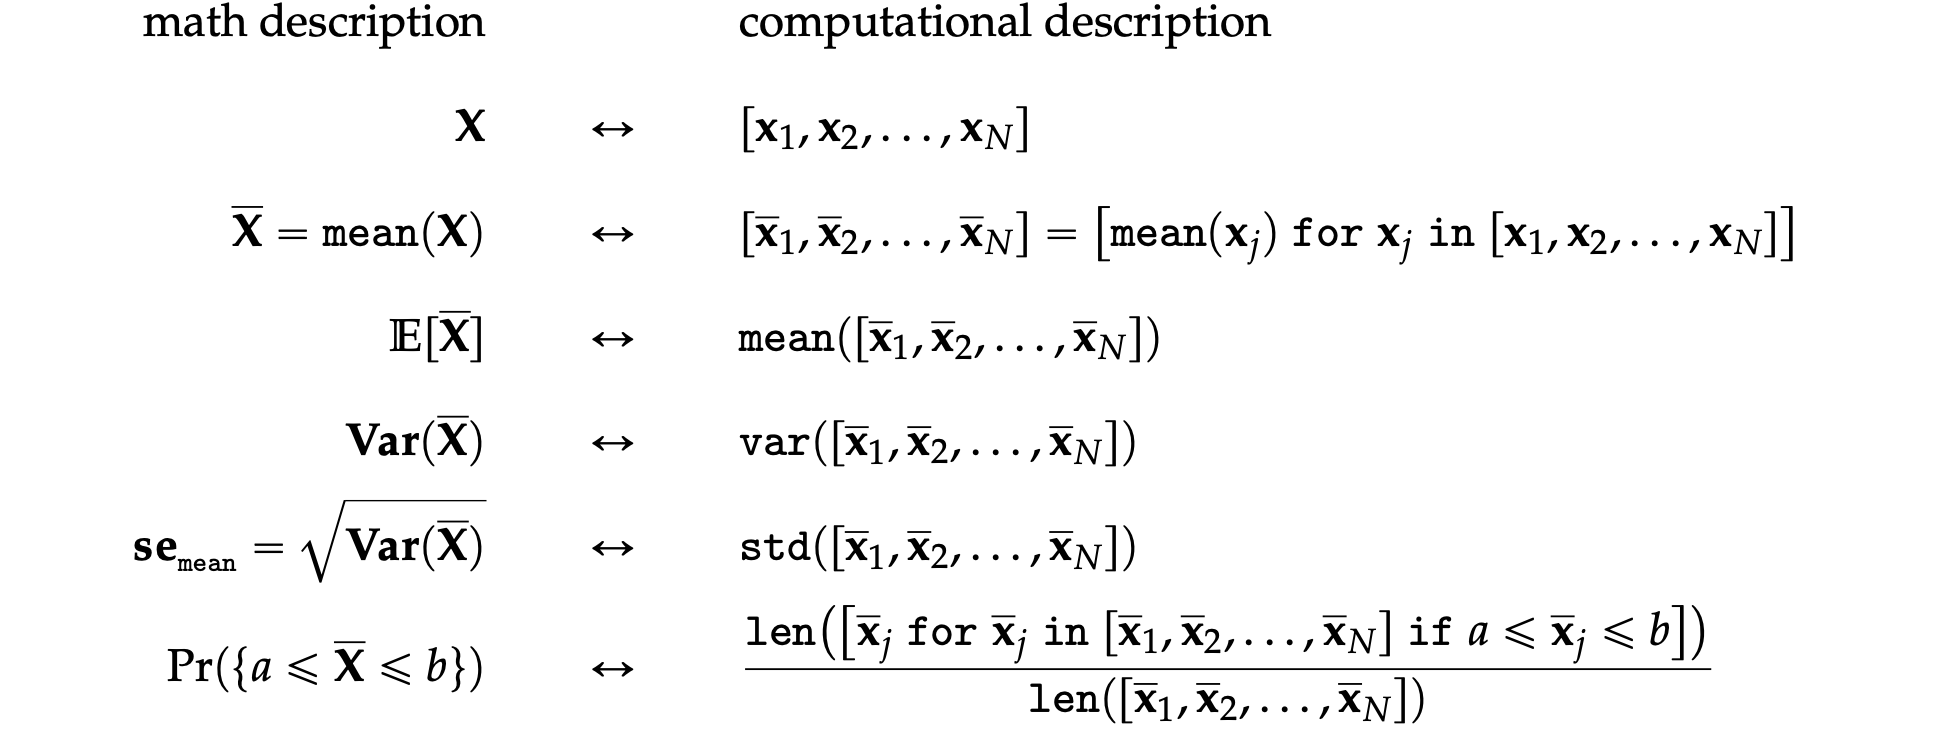


The two descriptions give us two different ways to do probability calculations. For example, we can visualize the sampling distribution of the estimator $\tt{mean}$, by plotting the probability density function of the random variable $\overline{\mathbf{X}} = \tt{mean}(\mathbf{X})$ or by plotting a histogram of the values $[\tt{mean}(\mathbf{x}_1), \tt{mean}(\mathbf{x}_2), \ldots, \tt{mean}(\mathbf{x}_N)]$.

Suppose someone asks us to compute the probability $\Pr(\{ a \leq \overline{\mathbf{X}} \leq b \})$, which describes the probability that the estimate computed from a random sample of size $n$ will be between $a$ and $b$. We can obtain the answer using the probability description by calculating the difference in the cumulative distribution function $\Pr(\{ a \leq \overline{\mathbf{X}} \leq b \}) = F_{\overline{\mathbf{X}}}(b) - F_{\overline{\mathbf{X}}}(a)$.  
Using the computational approach, we can obtain the same probability calculating by computing the \emph{proportion} of observations in the list $[\tt{mean}(\mathbf{x}_1), \tt{mean}(\mathbf{x}_2), \ldots, \tt{mean}(\mathbf{x}_N)]$ whose values are between $a$ and $b$. 


### Sampling distribution for different sample sizes

How is the sampling distribution of the mean affected by sample size?
To study this,
we'll generate samples of size $n=10$, $n=30$, and $n=100$
and inspect their meeans.

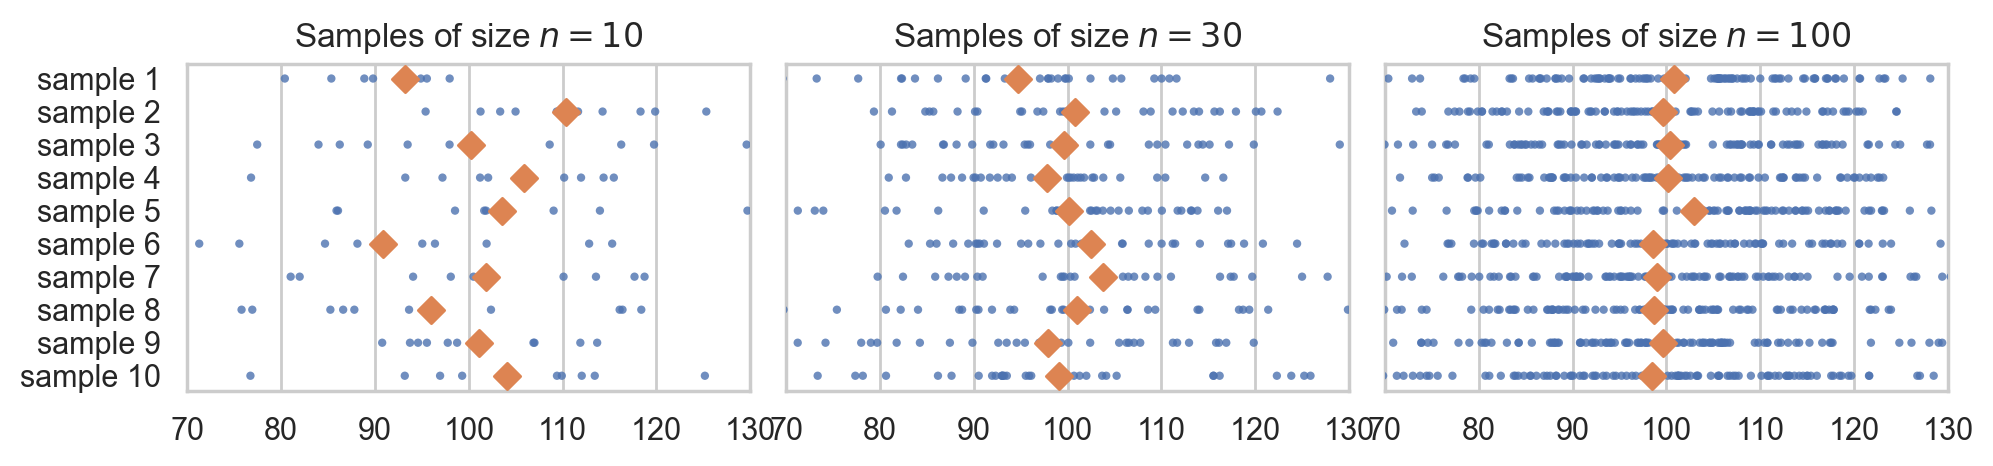

In [20]:
from ministats import plot_samples_panel
plot_samples_panel(rvX, xlims=[70,130])

savefig(plt.gcf(), "figures/samples_from_N10015_n10_n30_n100.png")

Let's now generate 10000 samples and plot he sampling distribution of the mean for each sample size.

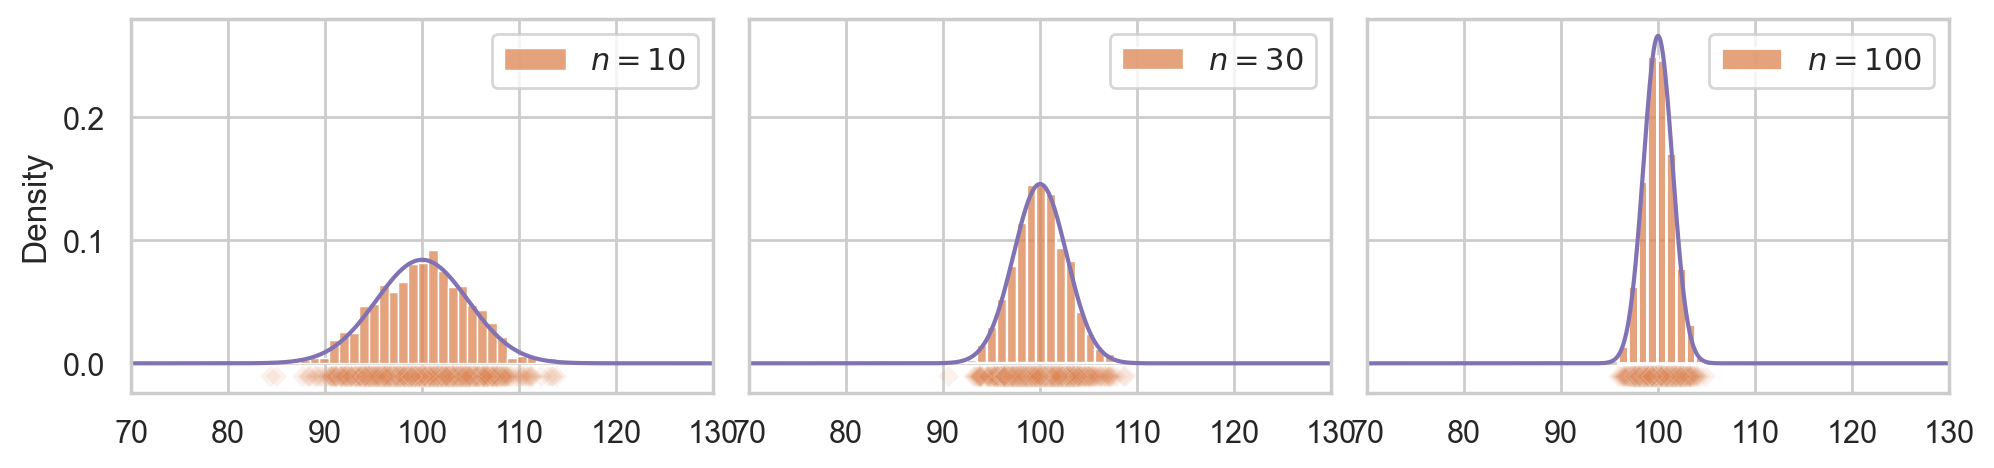

In [21]:
from ministats import plot_sampling_dists_panel
np.random.seed(47)
xbarss = plot_sampling_dists_panel(rvX, xlims=[70,130], binwidth=1)

savefig(plt.gcf(), "figures/sampling_dist_of_N10015_n10_n30_n100.png")

### Central limit theorem

The central limit theorem is a math formula for the sampling distribution of the mean. It is not an exact formula, but an analytical approximation that gets better and better with larger sample sizes. 

The formal statement of the theorem considers a random sample of size $n$ denoted $\mathbf{X} = (X_{1}, X_{2},\dots X_n)$, where each $X_i$ represents an independent draw from the random variable $X$. Let $\mu$ denote the mean of the random variable $X$, and let $\sigma$ denote the standard deviation of $X$. Then the sampling distribution of the mean $\overline{\mathbf{X}} = \frac{1}{n}\sum_{i=1}^n X_i$ will converge to a normal distribution:

$$
  \overline{\mathbf{X}}  \;\; \to \;\; \mathcal{N}\Big(\mu, \tfrac{\sigma}{\sqrt{n}} \Big),
$$
as the sample size $n$ goes to infinity.

The central limit theorem tells us three important facts:

- The mean of the sampling distribution $\overline{\mathbf{X}}$
  will approximately equal the population mean $\mu$.
  This means, if we use the sample mean to estimate the population mean,
  in the long term our estimates will be accurate.
- The second fact that the deviations of $\overline{\mathbf{X}}$
  from the true value $\mu$ will be normally distributed.
  No matter what population $X$ we start from (not necessary normal),
  the sample means will be normally distributed.
- The third fact is a precise math formula for the standard deviation
  of the sampling distribution as a function of the population
  standard deviation $\sigma$ and the sample size $n$:
  $\mathbf{se} = \frac{\sigma}{\sqrt{n}}$.

Recall the *standard error* is defined as the standard deviation of the sampling distribution.

### Verify central limit theorem

Let's see if the standard errors of the sampling distributions for samples of size $n=10$,
we have simulated are close to the formula predicted by the central limit theorem.

First use simulation to find the true value of the standard error.

In [22]:
N = 10000
xbars10 = [mean(rvX.rvs(10)) for j in range(0, N)]    
np.std(xbars10)

4.713454163708772

Let's compare these observations from the simulation,
to the theoretical standard deviations predicted by the CLT.

In [23]:
from math import sqrt
sigma / sqrt(10)

4.743416490252569

Let's now verify the predictions of the central limit theorem for samples of size $n=30$

In [24]:
xbars30 = [mean(rvX.rvs(30)) for j in range(0, N)]
np.std(xbars30), sigma/sqrt(30)

(2.726033995385025, 2.7386127875258306)

Finally,
let's check the predictions for $n=100$.

In [25]:
xbars100 = [mean(rvX.rvs(100)) for j in range(0, N)]
np.std(xbars100), sigma/sqrt(100)

(1.4930938336228587, 1.5)

We see there is quite close agreement between the central limit theorem formula for the standard error, and the formula gets more and more accurate for larger $n$.

## Hypothesis testing using simulation

TODO: import from blog post and slides

In [26]:
np.random.seed(55)

n = 30     # sample size
N = 10000  # number of simulated samples

xbars = []
for j in range(0, N):
    sample = rvX.rvs(n)
    xbar = mean(sample)
    xbars.append(xbar)

We have seen this before,
but now generate using $N=10000$ to get higher presision.

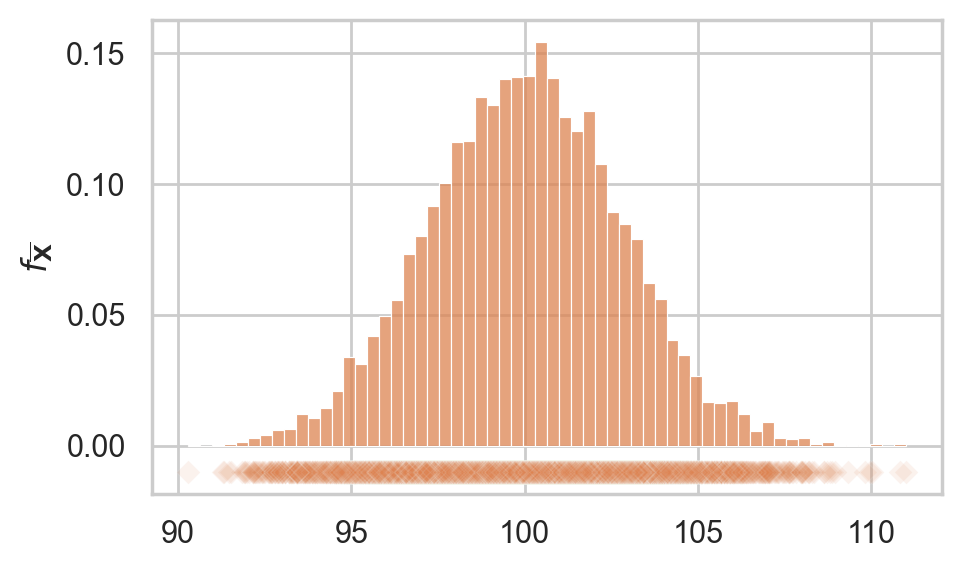

In [27]:
ax = sns.histplot(xbars, color="C1", stat="density")
sns.scatterplot(x=xbars, y=-0.01, color="C1", marker="D", alpha=0.1, ax=ax)
ax.set_ylabel("$f_{\\overline{\\mathbf{X}}}$")
savefig(plt.gcf(), "figures/hist_sampling_dist_mean_rvX_n30_N10000.png")

In [28]:
obsmean = mean(iqs)
obsmean

105.89

In [29]:
tail = [xbar for xbar in xbars if xbar > obsmean]
pvalue = len(tail) / len(xbars)
pvalue

0.0184

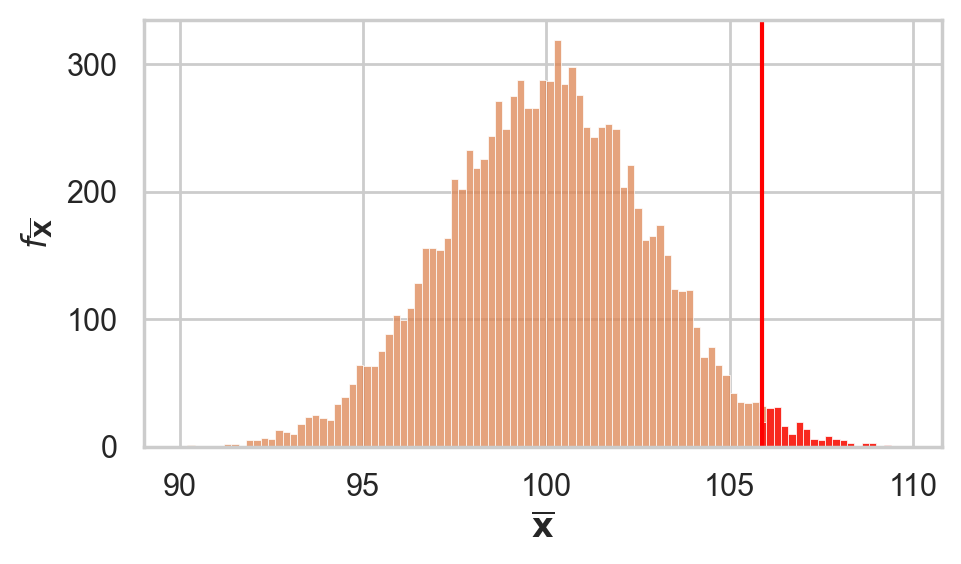

In [30]:
# plot the sampling distribution
bins = np.arange(90, 110, 0.2)
ax = sns.histplot(xbars, bins=bins, color="C1")

# plot red line for the observed statistic
plt.axvline(obsmean, color="red")

# plot the values that are equal or more extreme in red
sns.histplot(tail, ax=ax, bins=bins, color="red")
_ = ax.set_ylabel("$f_{\\overline{\\mathbf{X}}}$")
_ = ax.set_xlabel("$\\overline{\\mathbf{x}}$")

savefig(plt.gcf(), "figures/pvalue_viz_simulation_test_iqs.png")

#### Alternative $p$-value calculation using formula

In [31]:
from ministats import ttest_mean
ttest_mean(iqs, mu0=100, alt="greater")

0.01792942680682752

### Bootstrap estimation

TODO: import from blog post and slides

Generate 5000 bootstrap samples (sampling with replacement) from the sample `iqs`.
Use the bootstrap samples to approximate the sampling distribution of the mean.

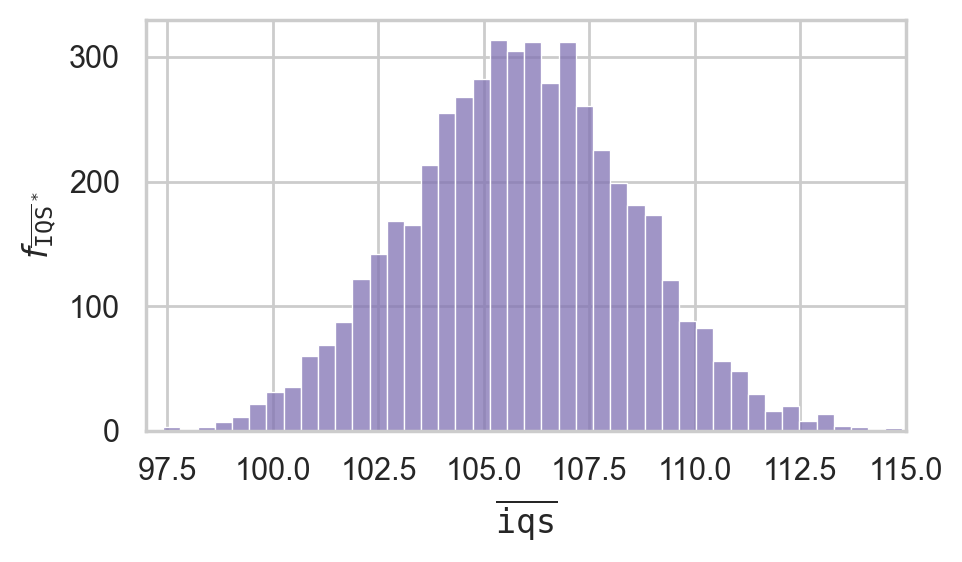

In [32]:
np.random.seed(46)

n = 30    # sample size
B = 5000  # number of bootstrap samples

bmeans = []
for i in range(0, B):
    bsample = np.random.choice(iqs, n, replace=True)
    bmean = mean(bsample)
    bmeans.append(bmean)

ax = sns.histplot(bmeans, color="C4")
ax.set_xlim(97,115)
ax.set_ylabel("$f_{\\overline{\\tt{IQS}}^*}$")
ax.set_xlabel("$\\overline{\\tt{iqs}}$")

savefig(plt.gcf(), "figures/bootstrap_dist_mean_iqs.png")

In [33]:
ci90 = np.percentile(bmeans, [5, 95])
ci90.round(2)

array([101.52, 110.16])

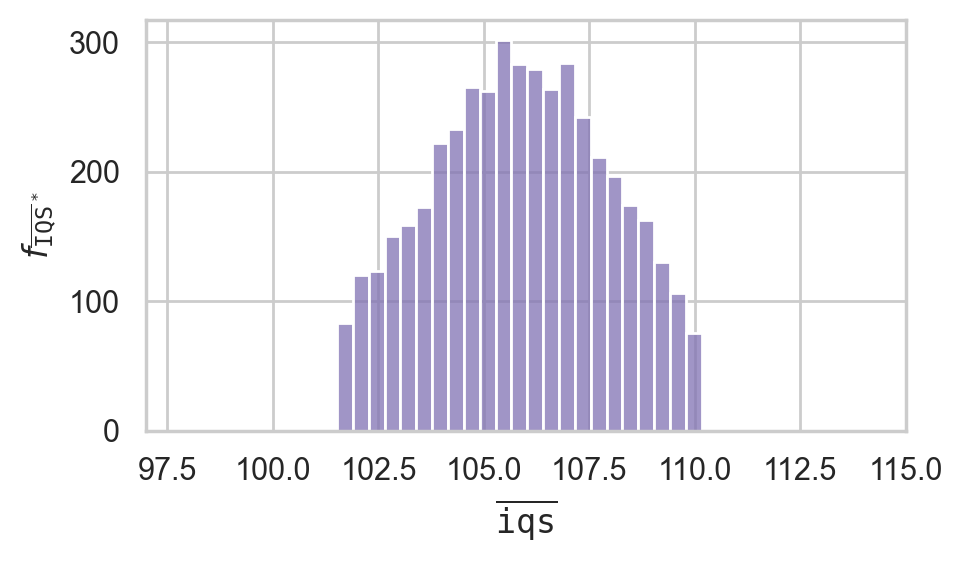

In [34]:
bulk = [x for x in bmeans if x > ci90[0] and x < ci90[1]]
ax = sns.histplot(bulk, color="C4")
ax.set_xlim(97,115)
ax.set_ylabel("$f_{\\overline{\\tt{IQS}}^*}$")
ax.set_xlabel("$\\overline{\\tt{iqs}}$")

savefig(plt.gcf(), "figures/bootstrap_dist_mean_iqs_ci.png")

#### Alternative using formula

In [35]:
from ministats import ci_mean
ci_mean(iqs, alpha=0.1)

[101.34277195122348, 110.43722804877652]

### Permutation test

TODO: import from blog post and slides

Suppose we have a obtained samples from group of students who took the smart drug `treated`,
and a similar group who didn't take the smart drug `controls`.

In [36]:
# data

treated = [92.69, 117.15, 124.79, 100.57, 104.27, 121.56, 104.18,
           122.43, 98.85, 104.26, 118.56, 138.98, 101.33, 118.57, 
           123.37, 105.9, 121.75, 123.26, 118.58, 80.03, 121.15, 
           122.06, 112.31, 108.67, 75.44, 110.27, 115.25, 125.57,
           114.57, 98.09, 91.15, 112.52, 100.12, 115.2, 95.32, 
           121.37, 100.09, 113.8, 101.73, 124.9, 87.83, 106.22, 
           99.97, 107.51, 83.99, 98.03, 71.91, 109.99, 90.83, 105.48]

controls = [85.1, 84.05, 90.43, 115.92, 97.64, 116.41, 68.88, 110.51, 
            125.12, 94.04, 134.86, 85.0, 91.61, 69.95, 94.51, 81.16, 
            130.61, 108.93, 123.38, 127.69, 83.36, 76.97, 124.87, 86.36, 
            105.71, 93.01, 101.58, 93.58, 106.51, 91.67, 112.93, 88.74, 
            114.05, 80.32, 92.91, 85.34, 104.01, 91.47, 109.2, 104.04, 
            86.1, 91.52, 98.5, 94.62, 101.27, 107.41, 100.68, 114.94, 
            88.8, 121.8]


To compare the two groups,
we'll subtract the average score computed from each group.

In [37]:
def dmeans(xsample, ysample):
    dhat = mean(xsample) - mean(ysample)
    return dhat

# Calculate the observed difference between means
dscore = dmeans(treated, controls)
dscore

7.8870000000000005

### Statistical question?

Are the two groups the same?
This is equivalent to saying the smart drug had no effect.

### Disproving the skeptical colleague

We'll now use the `10000` permutations of the original data
to obtain sampling distribution of the difference between means under the null hypothesis.

In [38]:
np.random.seed(43)

pdhats = []
for i in range(0, 10000):
    all_iqs = np.concatenate((treated, controls))
    pall_iqs = np.random.permutation(all_iqs)
    ptreated = pall_iqs[0:len(treated)]
    pcontrols = pall_iqs[len(treated):]
    pdhat = dmeans(ptreated, pcontrols)
    pdhats.append(pdhat)

Compute the p-value of the observed difference between means `dprice` under the null hypothesis.

In [39]:
tails = [d for d in pdhats if abs(d) > dscore]
pvalue = len(tails) / len(pdhats)
pvalue

0.0101

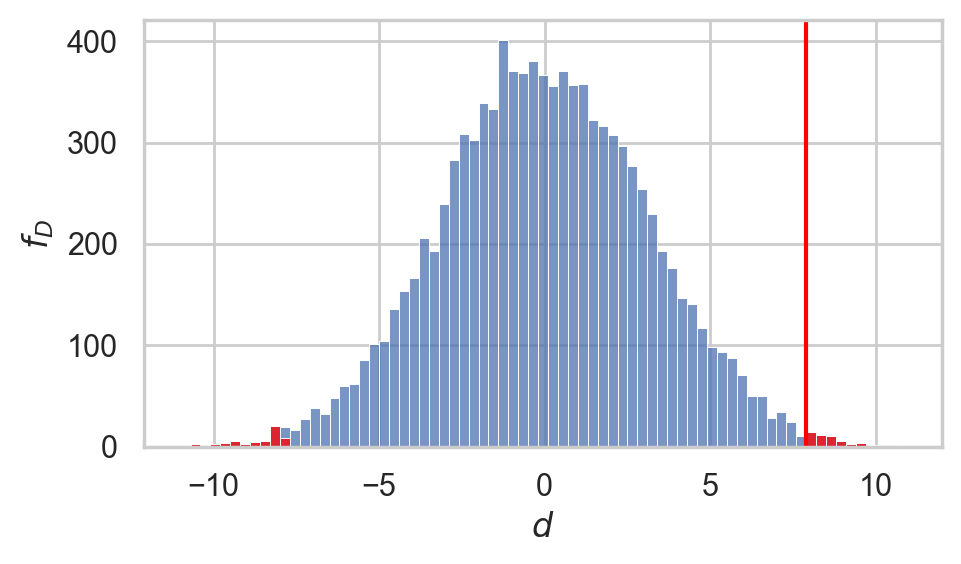

In [40]:
bins = np.arange(-11, 11, 0.3)

# plot the sampling distribution in blue
ax = sns.histplot(pdhats, bins=bins)

# plot red line for the observed statistic
plt.axvline(dscore, color="red")

# plot the values that are equal or more extreme in red
sns.histplot(tails, ax=ax, bins=bins, color="red")
ax.set_xlabel("$d$")
ax.set_ylabel("$f_{D}$")

savefig(plt.gcf(), "figures/pvalue_viz_permutation_test_iqs.png")

#### Alternative using formula

In [41]:
from ministats import ttest_dmeans
ttest_dmeans(treated, controls)

0.010163611652137501

## Conclusion

## Links

- [Python tutorial](https://nobsstats.com/tutorials/python_tutorial.html)
- Previous blog posts:
  - [Outline of the stats curriculum research](https://minireference.com/blog/fixing-the-introductory-statistics-curriculum/)
  - [Book proposal](https://minireference.com/blog/no-bullshit-guide-to-statistics-progress-update/)
  - [Stats survey results](https://minireference.com/blog/what-stats-do-people-want-to-learn/)
  - [Python coding skills for statistics](https://minireference.com/blog/python-for-stats/)
- Book website [noBSstats.com](https://nobsstats.com/intro.html): contains all the notebooks, demos, and visualizations from the book.
- Great talks on resampling methods:
  - [Statistics for Hackers](https://www.youtube.com/watch?v=Iq9DzN6mvYA) talk by Jake Vanderplas
  - [There's Only One Test](https://www.youtube.com/watch?v=S41zQEshs5k) talk by Allen B. Downey

<!-- 
- [Detailed book outline](https://docs.google.com/document/d/1fwep23-95U-w1QMPU31nOvUnUXE2X3s_Dbk5JuLlKAY/edit): continuously updated list of the topics that are covered in each section.
- [Pandas tutorial](https://nobsstats.com/tutorials/pandas_tutorial.html)
- [Seaborn tutorial](https://nobsstats.com/tutorials/seaborn_tutorial.html)
-->
